In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import squigglepy as sq

from metr import fit_metr, load_metr_data

In [8]:
df = load_metr_data("data/benchmark_results.yaml")
fit = fit_metr(df)

print(
    f"h50 fit: log(h) = {fit.intercept_50:.4f} + {fit.slope_50:.5f} * t "
    f"(R² = {fit.r_squared_50:.3f})"
)
print(
    f"h80 fit: log(h) = {fit.intercept_80:.4f} + {fit.slope_80:.5f} * t "
    f"(R² = {fit.r_squared_80:.3f})"
)
print(f"Doubling time: {fit.doubling_time_months:.2f} months")

h50 fit: log(h) = -3.9177 + 0.10440 * t (R² = 0.888)
h80 fit: log(h) = -5.5074 + 0.10307 * t (R² = 0.887)
Doubling time: 6.64 months


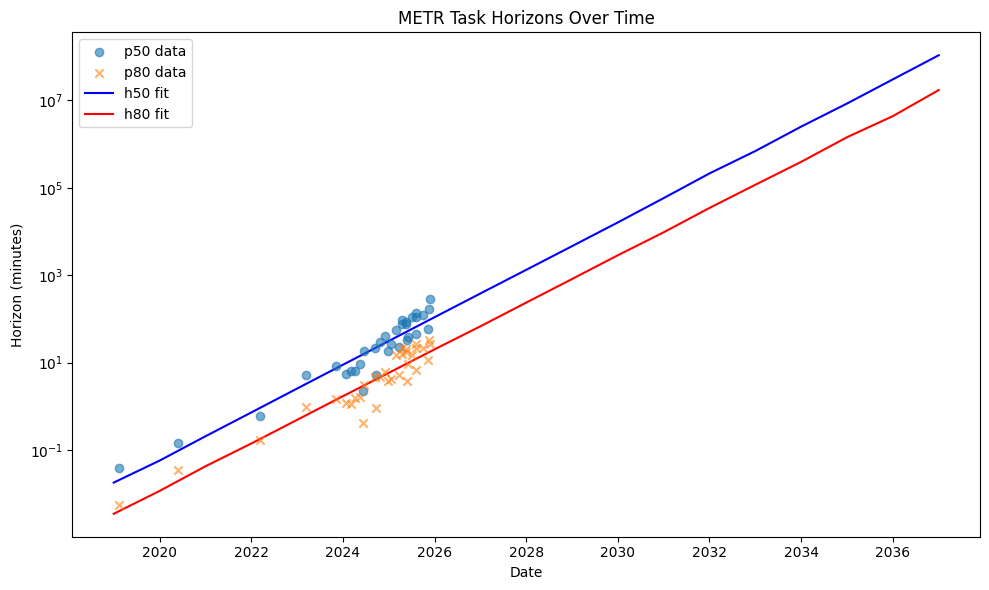

In [3]:
years = range(fit.base_date.year, 2038)
dates = [date(y, 1, 1) for y in years]
t_months = [(d - fit.base_date).days / 30.44 for d in dates]
n_samples = 500

# %% Cell 4 - Plot h50 and h80 over time
fig, ax = plt.subplots(figsize=(10, 6))

# Data points
ax.scatter(df["release_date"], df["p50_horizon"], alpha=0.6, label="p50 data", zorder=3)
ax.scatter(df["release_date"], df["p80_horizon"], alpha=0.6, label="p80 data", zorder=3, marker="x")

# Sample horizons at each date
h50_samples = np.array([fit.sample_horizons(t, n=n_samples)[0] for t in t_months])
h80_samples = np.array([fit.sample_horizons(t, n=n_samples)[1] for t in t_months])

h50_median = np.median(h50_samples, axis=1)
h80_median = np.median(h80_samples, axis=1)

ax.plot(dates, h50_median, "b-", label="h50 fit")
ax.plot(dates, h80_median, "r-", label="h80 fit")

ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Horizon (minutes)")
ax.set_title("METR Task Horizons Over Time")
ax.legend()
plt.tight_layout()
plt.show()

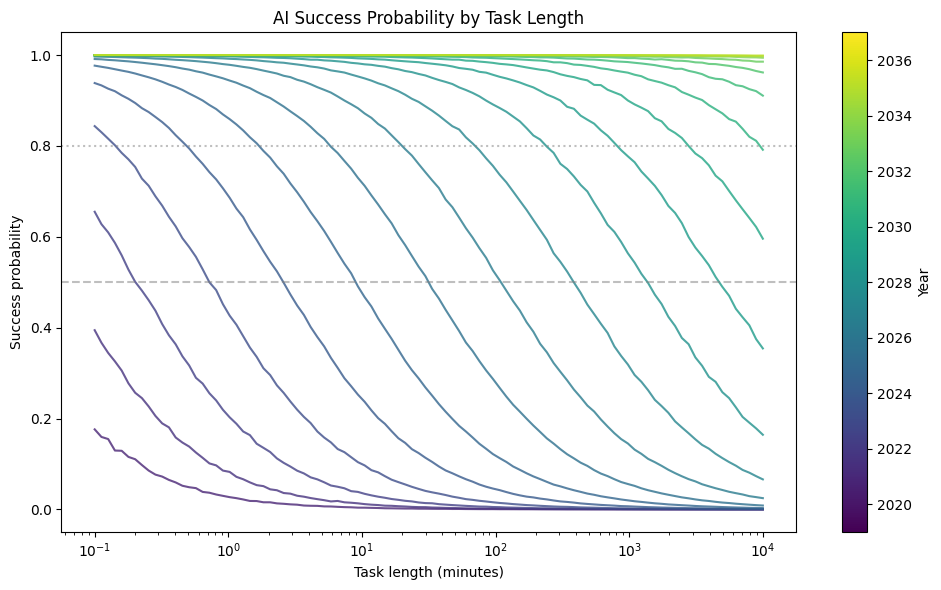

In [4]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(10, 6))

task_range_min = np.logspace(-1, 4, 100)  # 0.1 min to 10,000 min

# Color gradient from light to dark
colors = cm.viridis(np.linspace(0.1, 0.9, len(years)))

for i, year in enumerate(years):
    d = date(year, 1, 1)
    t = (d - fit.base_date).days / 30.44

    # Median success probability at each task length
    probs = np.array(
        [np.median(fit.success_probability(task, t, n=n_samples)) for task in task_range_min]
    )
    ax.plot(task_range_min, probs, color=colors[i], alpha=0.8)

ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="50%")
ax.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="80%")
ax.set_xscale("log")
ax.set_xlabel("Task length (minutes)")
ax.set_ylabel("Success probability")
ax.set_title("AI Success Probability by Task Length")

# Add colorbar for years
sm = cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(min(years), max(years)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Year")

plt.tight_layout()
plt.show()

In [5]:
sw_task_distribution = sq.lognorm(10, 480)  # 90% CI: 10 min to 8 hr

n_tasks = 100000
task_durations = sw_task_distribution @ n_tasks
total_volume = np.sum(task_durations)

rows = []
for d, t in zip(dates, t_months):
    # Sample horizons once per date
    h50, h80 = fit.sample_horizons(t, n=n_samples)
    k = np.log(0.25) / np.log(h80 / h50)

    for i in range(n_samples):
        # Compute expected automated volume using success probability curve
        # Numerically stable calculation
        log_ratio = k[i] * np.log(task_durations / h50[i])
        log_ratio = np.clip(log_ratio, -50, 50)
        probs = 1 / (1 + np.exp(log_ratio))
        automated_volume = np.sum(task_durations * probs)
        frac_automated = automated_volume / total_volume
        speedup = 1 / (1 - frac_automated)

        rows.append(
            {
                "date": d,
                "h50": h50[i],
                "h80": h80[i],
                "k": k[i],
                "frac_automated": frac_automated,
                "speedup": speedup,
            }
        )

results = pd.DataFrame(rows)

# Summarize by year
summary = (
    results.groupby("date")
    .agg(
        h50_median=("h50", "median"),
        h80_median=("h80", "median"),
        k_median=("k", "median"),
        frac_automated_median=("frac_automated", "median"),
        speedup_median=("speedup", "median"),
        speedup_p5=("speedup", lambda x: np.percentile(x, 5)),
        speedup_p95=("speedup", lambda x: np.percentile(x, 95)),
    )
    .reset_index()
)

print(summary.to_string(index=False))

      date   h50_median   h80_median  k_median  frac_automated_median  speedup_median  speedup_p5   speedup_p95
2019-01-01 1.735781e-02 3.493868e-03  0.874200               0.000376        1.000376    1.000063      1.001263
2020-01-01 5.904044e-02 1.148343e-02  0.857821               0.001178        1.001179    1.000351      1.002991
2021-01-01 2.076336e-01 4.136440e-02  0.854861               0.003480        1.003492    1.001401      1.006900
2022-01-01 7.471579e-01 1.460091e-01  0.845751               0.010550        1.010663    1.006208      1.017459
2023-01-01 2.513237e+00 4.927573e-01  0.838179               0.029191        1.030069    1.021938      1.041503
2024-01-01 9.046544e+00 1.709565e+00  0.833475               0.077050        1.083483    1.067858      1.103603
2025-01-01 3.131313e+01 5.811421e+00  0.825072               0.176986        1.215046    1.182233      1.252595
2026-01-01 1.097612e+02 1.992891e+01  0.815279               0.345327        1.527480    1.437818      1

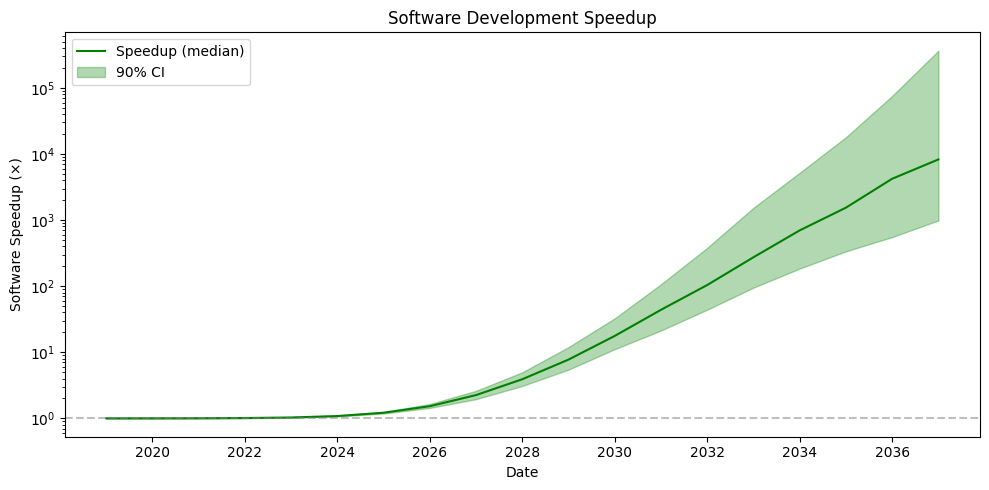

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(summary["date"], summary["speedup_median"], "g-", label="Speedup (median)")
ax.fill_between(
    summary["date"],
    summary["speedup_p5"],
    summary["speedup_p95"],
    alpha=0.3,
    color="green",
    label="90% CI",
)
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Software Speedup (×)")
ax.set_title("Software Development Speedup")
ax.legend(loc="upper left")
ax.axhline(y=1, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()